**Sorular:**
1. Fraud oranı ve sınıf dengesizliği
2. Identity bilgisi olan/olmayan işlemlerde fraud oranı
3. addr / dist / R_emaildomain boşluklarının fraud ile ilişkisi
4. Tekrar eden işlem kümesi (102 satır) ve fraud oranı
5. TransactionAmt dağılımı
6. TransactionDT'den saat/gün örüntüleri
7. ProductCD / card / e-posta domain kırılımları

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Geniş tabloyu (434 sütun) incelerken pandas'ın sütunları "..." ile kısaltmasını azaltıyoruz
pd.set_option("display.max_columns", 60)
sns.set_theme(style="whitegrid")

DATA_DIR = Path("../data")

df = pd.read_parquet(DATA_DIR / "train_merged.parquet")

In [2]:
print("Boyut:", df.shape)

Boyut: (590537, 434)


In [3]:
print(df.dtypes.value_counts())

float32     399
category     12
category      4
int32         2
int8          1
category      1
int16         1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
Name: count, dtype: int64


In [4]:
# Hedef değişken (isFraud) dağılımı

counts = df["isFraud"].value_counts().sort_index()
fraud_rate = df["isFraud"].mean()

print(counts)
print(f"\nFraud oranı: %{fraud_rate * 100:.2f}")

print(f"Dengesizlik: 1 fraud'a karşı ~{counts[0] / counts[1]:.0f} normal işlem")

isFraud
0    569874
1     20663
Name: count, dtype: int64

Fraud oranı: %3.50
Dengesizlik: 1 fraud'a karşı ~28 normal işlem


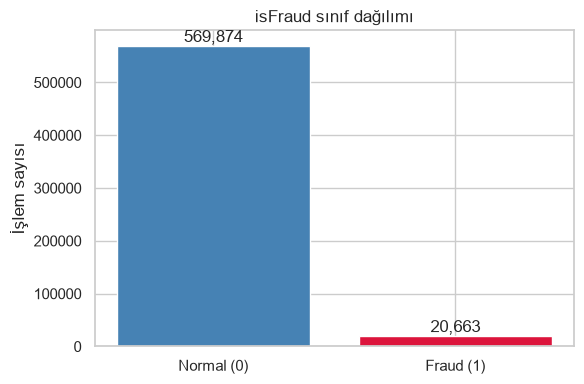

In [5]:
# Görselleştirme
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(["Normal (0)", "Fraud (1)"], counts.values, color=["steelblue", "crimson"])
ax.bar_label(bars, labels=[f"{v:,}" for v in counts.values])
ax.set_title("isFraud sınıf dağılımı")
ax.set_ylabel("İşlem sayısı")
plt.tight_layout()
fig.savefig("../src/02_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [6]:
# has_identity bayrağı ve fraud oranı

df["has_identity"] = df["id_01"].notna().astype("int8")
print("Identity kaydı olan işlem sayısı:", df["has_identity"].sum())

Identity kaydı olan işlem sayısı: 144233


In [7]:
# Grup bazında özet: işlem sayısı, fraud sayısı, fraud oranı
identity_summary = (
    df.groupby("has_identity")["isFraud"]
      .agg(islem_sayisi="count", fraud_sayisi="sum", fraud_orani="mean")
)
identity_summary["fraud_orani_%"] = (identity_summary["fraud_orani"] * 100).round(2)

# Genel orana göre kaç kat?
identity_summary["genel_orana_gore_kat"] = (identity_summary["fraud_orani"] / fraud_rate).round(2)

print(identity_summary.drop(columns="fraud_orani"))


              islem_sayisi  fraud_sayisi  fraud_orani_%  genel_orana_gore_kat
has_identity                                                                 
0                   446304          9345           2.09                  0.60
1                   144233         11318           7.85                  2.24


In [8]:
#  Seçili sütunlarda boşluk (NaN) ile fraud ilişkisi

cols = ["addr1", "addr2", "dist1", "dist2", "P_emaildomain", "R_emaildomain"]

rows = []

for col in cols:

    is_missing = df[col].isna()

    rows.append({
        "sutun": col,
        "bos_orani_%": is_missing.mean() * 100,
        "fraud_%_bos": df.loc[is_missing, "isFraud"].mean() * 100,
        "fraud_%_dolu": df.loc[~is_missing, "isFraud"].mean() * 100,
    })

missing_summary = pd.DataFrame(rows).set_index("sutun").round(2)

missing_summary["kat_bos/dolu"] = (
    missing_summary["fraud_%_bos"] / missing_summary["fraud_%_dolu"]
).round(2)

print(missing_summary)

               bos_orani_%  fraud_%_bos  fraud_%_dolu  kat_bos/dolu
sutun                                                              
addr1                11.13        11.78          2.46          4.79
addr2                11.13        11.78          2.46          4.79
dist1                59.65         4.52          2.00          2.26
dist2                93.63         3.06          9.92          0.31
P_emaildomain        15.99         2.95          3.60          0.82
R_emaildomain        76.75         2.08          8.18          0.25


In [9]:
print("addr1 ve addr2 aynı satırlarda boş mu?:",
      (df["addr1"].isna() == df["addr2"].isna()).all())

r_email_filled = df["R_emaildomain"].notna().rename("R_email_dolu")
print(
    (pd.crosstab(df["has_identity"], r_email_filled, normalize="columns") * 100).round(1)
)

addr1 ve addr2 aynı satırlarda boş mu?: True
R_email_dolu  False  True 
has_identity              
0              97.1    4.5
1               2.9   95.5


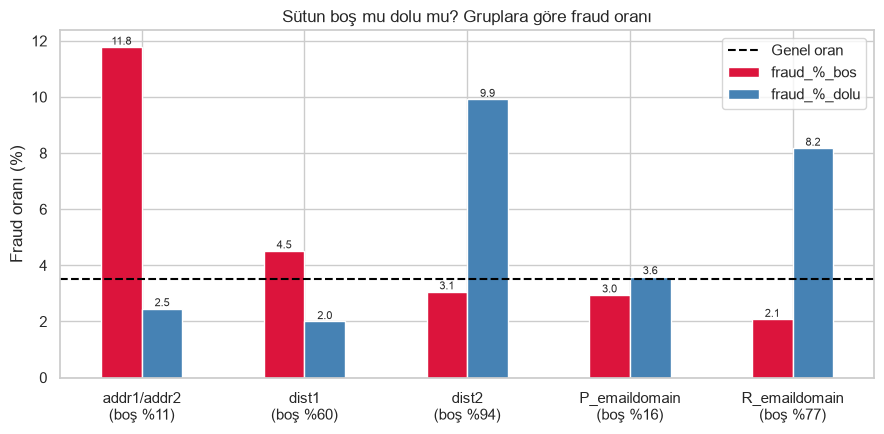

In [10]:
plot_df = missing_summary.drop(index="addr2")

fig, ax = plt.subplots(figsize=(9, 4.5))
plot_df[["fraud_%_bos", "fraud_%_dolu"]].plot(
    kind="bar", ax=ax, color=["crimson", "steelblue"], label=["Boş", "Dolu"]
)
ax.axhline(fraud_rate * 100, color="black", linestyle="--", label="Genel oran")

# Her çubuğun üstüne değerini yaz (ax.containers = çizilen çubuk grupları)
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", fontsize=8)

# Sütun adının altına boş oranını ekle -> örn. "dist2\n(boş %94)"
# \n alt satıra geçer; addr1'i "addr1/addr2" diye adlandırıyoruz
labels = [
    f"{'addr1/addr2' if c == 'addr1' else c}\n(boş %{plot_df.loc[c, 'bos_orani_%']:.0f})"
    for c in plot_df.index
]
ax.set_xticklabels(labels, rotation=0)

ax.set_title("Sütun boş mu dolu mu? Gruplara göre fraud oranı")
ax.set_ylabel("Fraud oranı (%)")
ax.set_xlabel("")
ax.legend()  # label'ları yukarıda verdiğimiz için sıra otomatik doğru gelir
plt.tight_layout()

fig.savefig("../src/02_fraud_by_missingness.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
# Tekrar eden işlemleri bul 

def tekrar_ozeti(df, cols, ad):
    """
    df   : veri
    cols : 'aynı' saymak için karşılaştırılacak sütunlar
    ad   : çıktıda görünecek küme adı
    Döndürür: tekrar eden satırlar + grup_id sütunu
    """
    mask = df.duplicated(subset=cols, keep=False)
    d = df[mask].copy()

    d["grup_id"] = d.groupby(cols, dropna=False, observed=True).ngroup()

    print(f"===== {ad} =====")
    print("Tekrar eden işlem sayısı:", len(d))
    print("Grup sayısı:", d["grup_id"].nunique())
    print(f"Fraud oranı: %{d['isFraud'].mean() * 100:.1f}  (genel: %{fraud_rate * 100:.1f})")

    # Grup büyüklüğü dağılımı: kaç grupta 2 işlem, kaçında 3 ...
    print("\nGrup büyüklüğü -> grup sayısı:")
    print(d["grup_id"].value_counts().value_counts().sort_index())

    grup_fraud = d.groupby("grup_id")["isFraud"].mean()
    print("\nGrupların fraud durumu:")
    print(pd.cut(grup_fraud, bins=[-0.01, 0, 0.99, 1],
                 labels=["hiç fraud yok", "karışık", "hepsi fraud"]).value_counts())
    print()
    return d


# Küme A: aynı anda, aynı kart, aynı tutar
key_cols = ["TransactionDT", "TransactionAmt", "card1", "card2", "card3",
            "card4", "card5", "card6", "ProductCD"]
dup_A = tekrar_ozeti(df, key_cols, "Küme A: aynı anda, aynı kart/tutar")

# Küme B: ID ve zaman hariç her şey aynı
dup_B = tekrar_ozeti(df, subset, "Küme B: farklı zamanda birebir tekrar")

===== Küme A: aynı anda, aynı kart/tutar =====
Tekrar eden işlem sayısı: 102
Grup sayısı: 41
Fraud oranı: %16.7  (genel: %3.5)

Grup büyüklüğü -> grup sayısı:
count
2    31
3     5
4     3
5     1
8     1
Name: count, dtype: int64

Grupların fraud durumu:
isFraud
hiç fraud yok    34
hepsi fraud       6
karışık           1
Name: count, dtype: int64



NameError: name 'subset' is not defined

In [ ]:
# TransactionAmt - normal vs fraud sayısal özet

amt_stats = (
    df.groupby("isFraud")["TransactionAmt"]
      .describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99])
      .T             
      .round(2)
)
amt_stats.columns = ["Normal", "Fraud"]  
print(amt_stats)

          Normal     Fraud
count  569874.00  20663.00
mean      134.51    149.24
std       239.40    232.21
min         0.25      0.29
25%        43.97     35.04
50%        68.50     75.00
75%       120.00    161.00
95%       435.00    500.00
99%      1104.00    994.00
max     31937.39   5191.00


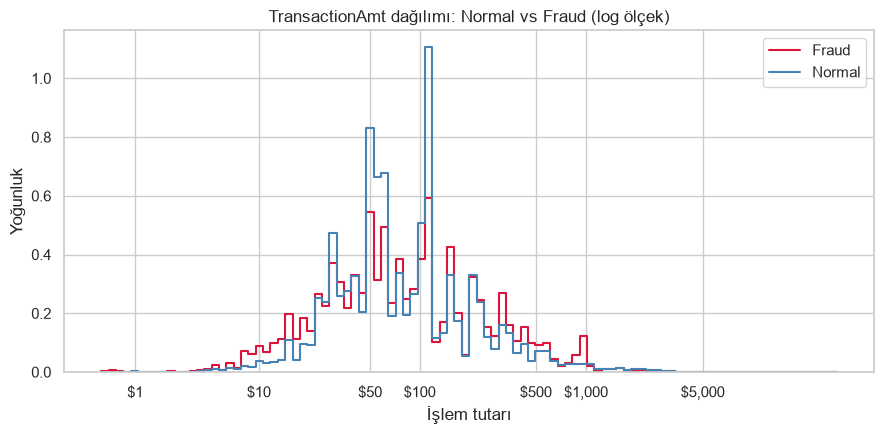

In [ ]:
# TransactionAmt dağılımı - normal vs fraud (log ölçek)

log_amt = np.log1p(df["TransactionAmt"])

fig, ax = plt.subplots(figsize=(9, 4.5))

sns.histplot(
    x=log_amt, hue=df["isFraud"], stat="density", common_norm=False,
    bins=100, element="step", fill=False, ax=ax,
    palette={0: "steelblue", 1: "crimson"},
)

dollar_ticks = [1, 10, 50, 100, 500, 1000, 5000]
ax.set_xticks(np.log1p(dollar_ticks))
ax.set_xticklabels([f"${t:,}" for t in dollar_ticks])

ax.set_title("TransactionAmt dağılımı: Normal vs Fraud (log ölçek)")
ax.set_xlabel("İşlem tutarı")
ax.set_ylabel("Yoğunluk")
ax.legend(["Fraud", "Normal"])  # hue sırası ters gelebilir; grafikte renkleri kontrol et
plt.tight_layout()

fig.savefig("../src/02_amount_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# TransactionDT'den gün / saat / haftanın günü türetme

dt = df["TransactionDT"]

# Verinin kapsadığı zaman aralığı
print("Min TransactionDT:", dt.min())
print("Max TransactionDT:", dt.max())
print(f"Kapsanan süre: {(dt.max() - dt.min()) / 86400:.0f} gün")  # 86400 sn = 1 gün

df["tx_day"] = (dt // 86400).astype("int16")
df["tx_hour"] = ((dt // 3600) % 24).astype("int8")
df["tx_dow"] = (df["tx_day"] % 7).astype("int8")

print("\ntx_hour aralığı:", df["tx_hour"].min(), "-", df["tx_hour"].max())
print("tx_dow aralığı :", df["tx_dow"].min(), "-", df["tx_dow"].max())

Min TransactionDT: 86400
Max TransactionDT: 15811131
Kapsanan süre: 182 gün

tx_hour aralığı: 0 - 23
tx_dow aralığı : 0 - 6


         islem_sayisi  fraud_orani_%
tx_hour                             
0               37795           3.14
1               32797           3.13
2               26731           3.75
3               20802           3.83
4               14839           5.19
5                9701           7.03
6                6007           7.77
7                3704          10.61
8                2591           9.30
9                2479           9.00
10               3627           5.32
11               6827           3.88
12              12451           3.04
13              20315           2.29
14              28327           2.42
15              33859           2.54
16              38698           2.95
17              40723           3.15
18              41639           3.52
19              42115           3.47
20              41782           3.43
21              41641           3.40
22              41139           3.27
23              39948           3.70


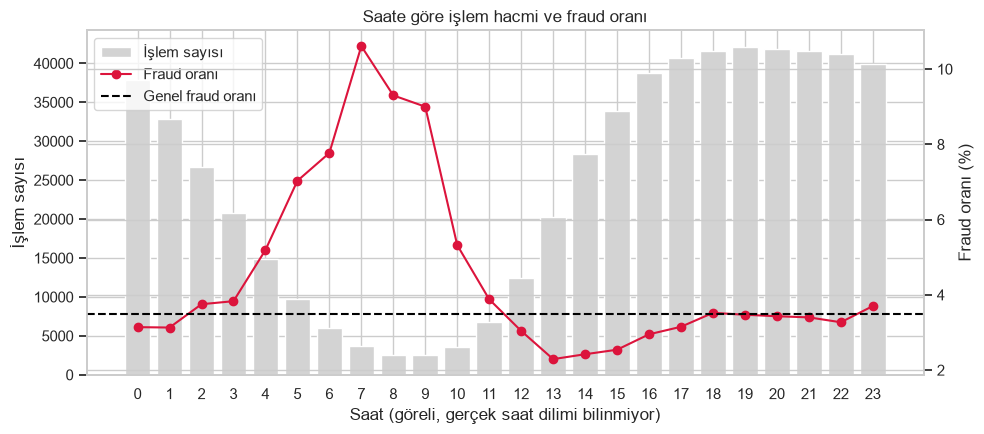

In [ ]:
# Saate göre işlem hacmi ve fraud oranı

hourly = df.groupby("tx_hour")["isFraud"].agg(islem_sayisi="count", fraud_orani="mean")
hourly["fraud_orani_%"] = (hourly["fraud_orani"] * 100).round(2)
print(hourly[["islem_sayisi", "fraud_orani_%"]])

fig, ax1 = plt.subplots(figsize=(10, 4.5))

# Sol eksen: işlem sayısı (çubuk)
ax1.bar(hourly.index, hourly["islem_sayisi"], color="lightgray", label="İşlem sayısı")
ax1.set_xlabel("Saat (göreli, gerçek saat dilimi bilinmiyor)")
ax1.set_ylabel("İşlem sayısı")
ax1.set_xticks(range(24))

ax2 = ax1.twinx()
ax2.plot(hourly.index, hourly["fraud_orani_%"], color="crimson", marker="o",
         label="Fraud oranı")
ax2.axhline(fraud_rate * 100, color="black", linestyle="--", label="Genel fraud oranı")
ax2.set_ylabel("Fraud oranı (%)")

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper left")

ax1.set_title("Saate göre işlem hacmi ve fraud oranı")
plt.tight_layout()

fig.savefig("../src/02_fraud_by_hour.png", dpi=150, bbox_inches="tight")
plt.show()

        islem_sayisi  fraud_orani_%
tx_dow                             
0              86374           3.72
1              98502           3.60
2              79834           3.71
3              70223           3.56
4              85433           3.15
5              84815           3.30
6              85356           3.45


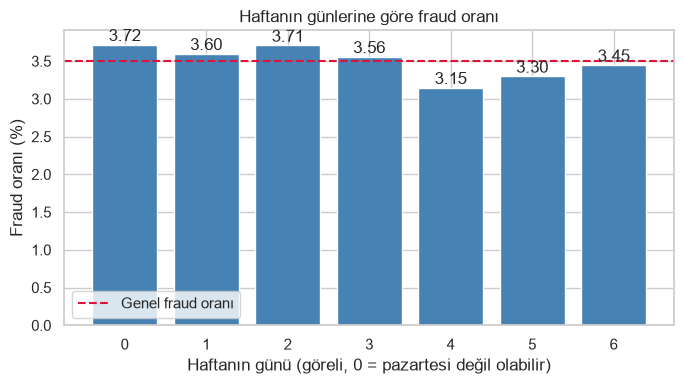

In [ ]:
# Haftanın günlerine göre işlem sayısı ve fraud oranı

dow = df.groupby("tx_dow")["isFraud"].agg(islem_sayisi="count", fraud_orani="mean")
dow["fraud_orani_%"] = (dow["fraud_orani"] * 100).round(2)
print(dow[["islem_sayisi", "fraud_orani_%"]])

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(dow.index, dow["fraud_orani_%"], color="steelblue")
ax.bar_label(bars, fmt="%.2f")  # çubukların üstüne oranı yaz
ax.axhline(fraud_rate * 100, color="crimson", linestyle="--", label="Genel fraud oranı")
ax.set_xticks(range(7))
ax.set_xlabel("Haftanın günü (göreli, 0 = pazartesi değil olabilir)")
ax.set_ylabel("Fraud oranı (%)")
ax.set_title("Haftanın günlerine göre fraud oranı")
ax.legend()
plt.tight_layout()

fig.savefig("../src/02_fraud_by_dow.png", dpi=150, bbox_inches="tight")
plt.show()

       islem_sayisi  fraud_orani_%
hafta                             
0             23810           2.81
1             27803           2.61
2             34470           2.55
3             37251           1.85
4             24041           3.82
5             21868           3.83
6             20392           3.86
7             20025           4.12
8             20246           4.55
9             23596           4.30
10            20860           4.31
11            19831           3.45
12            21733           3.90
13            27770           3.37
14            21901           3.26
15            20700           4.15
16            21003           5.06
17            23824           3.68
18            19622           3.53
19            18629           3.46
20            18460           3.59
21            20378           3.17
22            20740           2.85
23            20944           3.25
24            20206           3.67
25            17680           4.16
26             2754 

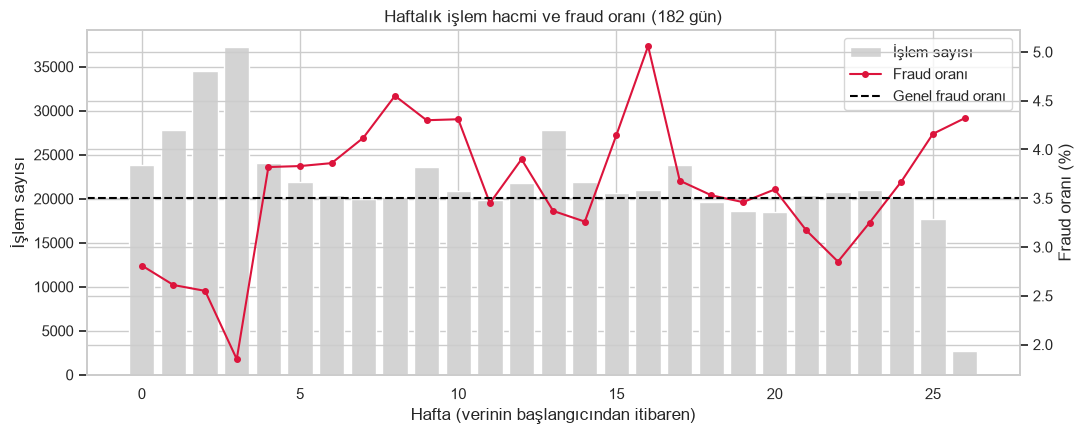

In [ ]:
# Haftalık işlem hacmi ve fraud oranı (6 aylık trend)

# tx_day // 7 -> kaçıncı hafta. Yeni sütun eklemeden doğrudan groupby'a veriyoruz.
week = (df["tx_day"] // 7).rename("hafta")
weekly = df.groupby(week)["isFraud"].agg(islem_sayisi="count", fraud_orani="mean")
weekly["fraud_orani_%"] = (weekly["fraud_orani"] * 100).round(2)
print(weekly[["islem_sayisi", "fraud_orani_%"]])

fig, ax1 = plt.subplots(figsize=(11, 4.5))

# Sol eksen: haftalık işlem sayısı (gri çubuk)
ax1.bar(weekly.index, weekly["islem_sayisi"], color="lightgray", label="İşlem sayısı")
ax1.set_xlabel("Hafta (verinin başlangıcından itibaren)")
ax1.set_ylabel("İşlem sayısı")

# Sağ eksen: haftalık fraud oranı (kırmızı çizgi) - saat grafiğindeki twinx mantığı
ax2 = ax1.twinx()
ax2.plot(weekly.index, weekly["fraud_orani_%"], color="crimson", marker="o",
         markersize=4, label="Fraud oranı")
ax2.axhline(fraud_rate * 100, color="black", linestyle="--", label="Genel fraud oranı")
ax2.set_ylabel("Fraud oranı (%)")

# İki eksenin legend'larını birleştir
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper right")

ax1.set_title("Haftalık işlem hacmi ve fraud oranı (182 gün)")
plt.tight_layout()

fig.savefig("../src/02_fraud_by_week.png", dpi=150, bbox_inches="tight")
plt.show()

           islem_sayisi  fraud_sayisi  islem_payi_%  fraud_payi_%  \
ProductCD                                                           
C                 68519          8008          11.6          38.8   
S                 11628           686           2.0           3.3   
H                 33024          1574           5.6           7.6   
R                 37699          1426           6.4           6.9   
W                439667          8969          74.5          43.4   

           fraud_orani_%  genel_orana_gore_kat  
ProductCD                                       
C                  11.69                  3.34  
S                   5.90                  1.69  
H                   4.77                  1.36  
R                   3.78                  1.08  
W                   2.04                  0.58  


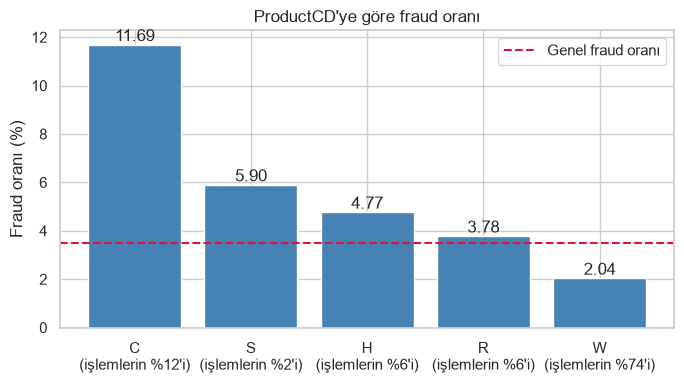

In [ ]:
# ProductCD bazında işlem sayısı, pay ve fraud oranı

prod = df.groupby("ProductCD", observed=True)["isFraud"].agg(
    islem_sayisi="count", fraud_sayisi="sum", fraud_orani="mean"
)

# bu ürün tüm işlemlerin yüzde kaçı?
prod["islem_payi_%"] = (prod["islem_sayisi"] / prod["islem_sayisi"].sum() * 100).round(1)
# Fraud payı: tüm fraud'ların yüzde kaçı bu üründe?
prod["fraud_payi_%"] = (prod["fraud_sayisi"] / prod["fraud_sayisi"].sum() * 100).round(1)
prod["fraud_orani_%"] = (prod["fraud_orani"] * 100).round(2)
prod["genel_orana_gore_kat"] = (prod["fraud_orani"] / fraud_rate).round(2)

# Fraud oranına göre büyükten küçüğe sırala
prod = prod.sort_values("fraud_orani", ascending=False)
print(prod.drop(columns="fraud_orani"))

# Grafik: fraud oranı çubukları + her çubuğun altına işlem payı
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(prod.index.astype(str), prod["fraud_orani_%"], color="steelblue")
ax.bar_label(bars, fmt="%.2f")
ax.axhline(fraud_rate * 100, color="crimson", linestyle="--", label="Genel fraud oranı")

# X ekseni etiketlerine işlem payını ekle: "W\n(%74)" gibi
ax.set_xticks(range(len(prod)))
ax.set_xticklabels([f"{p}\n(işlemlerin %{s:.0f}'i)"
                    for p, s in zip(prod.index, prod["islem_payi_%"])])
ax.set_ylabel("Fraud oranı (%)")
ax.set_title("ProductCD'ye göre fraud oranı")
ax.legend()
plt.tight_layout()

fig.savefig("../src/02_fraud_by_productcd.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ProductCD x has_identity - kafa karıştırıcı etki kontrolü

id_share = (pd.crosstab(df["ProductCD"], df["has_identity"], normalize="index") * 100).round(1)
id_share.columns = ["identity_yok_%", "identity_var_%"]
print("Her üründe identity payı:")
print(id_share)

pivot_rate = df.pivot_table(index="ProductCD", columns="has_identity",
                            values="isFraud", aggfunc="mean", observed=True) * 100
pivot_rate.columns = ["fraud_%_identity_yok", "fraud_%_identity_var"]

pivot_n = df.pivot_table(index="ProductCD", columns="has_identity",
                         values="isFraud", aggfunc="count", observed=True)
pivot_n.columns = ["n_identity_yok", "n_identity_var"]

print("\nÜrün içinde identity'ye göre fraud oranı:")
print(pd.concat([pivot_rate.round(2), pivot_n], axis=1))

Her üründe identity payı:
           identity_yok_%  identity_var_%
ProductCD                                
C                     9.2            90.8
H                     0.4            99.6
R                     0.4            99.6
S                     0.4            99.6
W                   100.0             0.0

Ürün içinde identity'ye göre fraud oranı:
           fraud_%_identity_yok  fraud_%_identity_var  n_identity_yok  \
ProductCD                                                               
C                          5.82                 12.28          6327.0   
H                          2.59                  4.77           116.0   
R                          1.99                  3.79           151.0   
S                          4.65                  5.90            43.0   
W                          2.04                   NaN        439667.0   

           n_identity_var  
ProductCD                  
C                 62192.0  
H                 32908.0  
R            

Saate göre ürün payları (%):
ProductCD     C    H    R    S     W
tx_hour                             
0          11.9  4.9  4.7  2.0  76.5
1          13.2  5.3  5.0  1.5  75.1
2          16.2  6.4  5.3  1.5  70.5
3          20.3  6.7  5.1  1.5  66.4
4          25.9  7.3  5.0  1.4  60.5
5          27.4  7.4  5.0  1.2  59.0
6          22.7  7.4  5.2  1.7  62.9
7          20.8  7.2  5.2  1.5  65.4
8          15.9  5.9  3.9  1.9  72.4
9           8.7  6.0  3.8  3.1  78.5
10          5.8  4.8  4.3  3.7  81.3
11          4.8  4.1  5.6  3.7  81.7
12          4.3  5.0  6.4  3.2  81.1
13          5.4  5.3  6.8  3.7  78.8
14          6.9  5.8  8.1  3.1  76.0
15          8.8  5.6  8.0  3.0  74.6
16         10.1  6.1  7.5  2.3  74.0
17         10.4  5.8  7.7  1.8  74.4
18         10.5  5.5  7.0  1.9  75.2
19         10.5  5.6  7.5  1.6  74.7
20         10.5  5.6  6.8  1.8  75.2
21         10.5  5.2  6.6  1.4  76.3
22         10.9  5.0  5.8  1.5  76.9
23         11.6  4.7  5.2  1.6  76.9


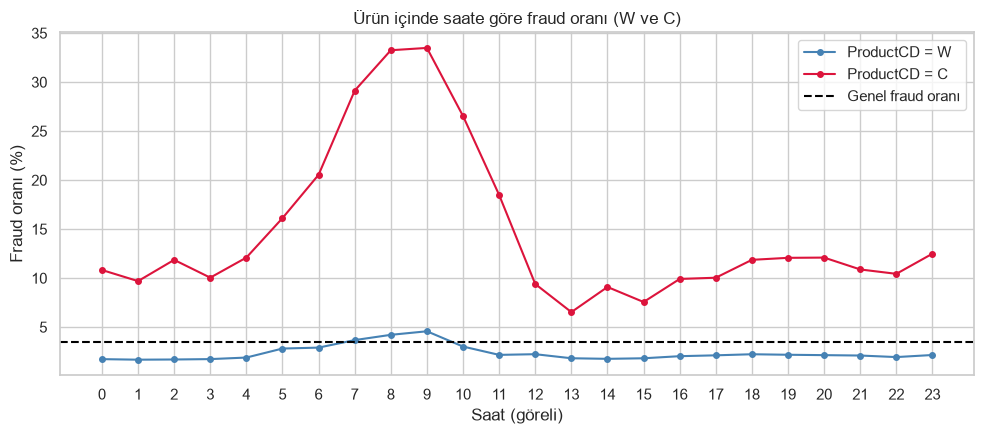

In [ ]:

# Saat x ProductCD - gece etkisi ürüne mi bağlı?

# Her saatte ürünlerin payı (satır içi yüzde: her saat kendi içinde %100)
hour_mix = (pd.crosstab(df["tx_hour"], df["ProductCD"], normalize="index") * 100).round(1)
print("Saate göre ürün payları (%):")
print(hour_mix)

#    satır = saat, sütun = ürün, hücre = fraud oranı (%)
hour_prod_rate = df.pivot_table(index="tx_hour", columns="ProductCD", values="isFraud",
                                aggfunc="mean", observed=True) * 100

# Grafik S/H/R gece saatlerinde çok az işleme düşer, çizgileri gürültülü olur.
fig, ax = plt.subplots(figsize=(10, 4.5))
for prod_code, color in [("W", "steelblue"), ("C", "crimson")]:
    ax.plot(hour_prod_rate.index, hour_prod_rate[prod_code],
            marker="o", markersize=4, color=color, label=f"ProductCD = {prod_code}")

ax.axhline(fraud_rate * 100, color="black", linestyle="--", label="Genel fraud oranı")
ax.set_xticks(range(24))
ax.set_xlabel("Saat (göreli)")
ax.set_ylabel("Fraud oranı (%)")
ax.set_title("Ürün içinde saate göre fraud oranı (W ve C)")
ax.legend()
plt.tight_layout()

fig.savefig("../src/02_fraud_by_hour_product.png", dpi=150, bbox_inches="tight")
plt.show()


W - en sık 5 tutar (ürün içindeki pay %):
TransactionAmt
59.000000     7.0
117.000000    6.6
107.949997    5.4
57.950001     5.4
49.000000     3.6

C - en sık 5 tutar (ürün içindeki pay %):
TransactionAmt
32.355999    0.5
33.534000    0.4
67.067001    0.3
64.712997    0.3
34.105000    0.3

H - en sık 5 tutar (ürün içindeki pay %):
TransactionAmt
50.0     29.8
100.0    17.5
25.0     14.0
75.0      7.3
150.0     6.6

R - en sık 5 tutar (ürün içindeki pay %):
TransactionAmt
100.0    31.4
150.0    15.0
200.0    13.6
50.0      9.3
250.0     7.1

S - en sık 5 tutar (ürün içindeki pay %):
TransactionAmt
50.0    13.2
25.0    12.6
20.0    10.5
30.0     7.7
10.0     7.2


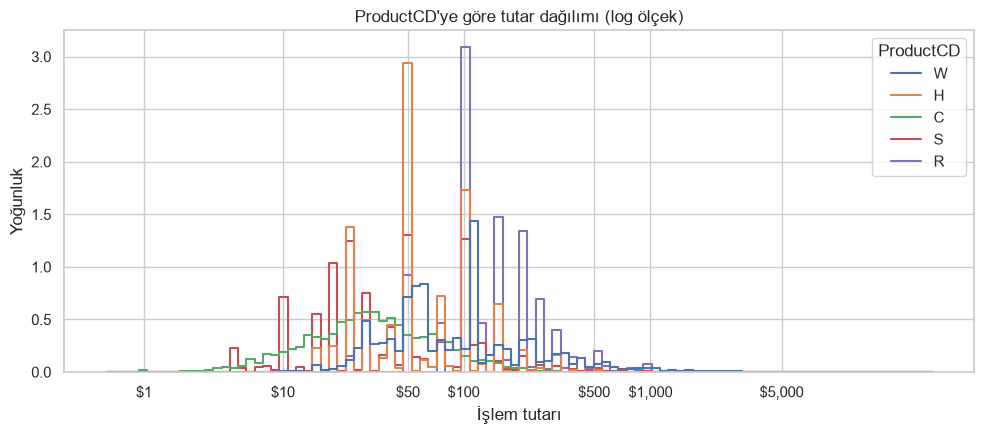

In [ ]:

# Ürün bazında en sık görülen tutarlar ve tutar dağılımı

for prod_code in ["W", "C", "H", "R", "S"]:
    amts = df.loc[df["ProductCD"] == prod_code, "TransactionAmt"]
    # value_counts(normalize=True): her tutarın oranı; head(5): en sık 5'i
    top5 = (amts.value_counts(normalize=True).head(5) * 100).round(1)
    print(f"\n{prod_code} - en sık 5 tutar (ürün içindeki pay %):")
    print(top5.to_string())  # to_string: alt satırdaki 'Name/dtype' bilgisini gizler

# Grafik
fig, ax = plt.subplots(figsize=(10, 4.5))
sns.histplot(
    x=np.log1p(df["TransactionAmt"]), hue=df["ProductCD"].astype(str),
    stat="density", common_norm=False,  
    bins=100, element="step", fill=False, ax=ax,
)
dollar_ticks = [1, 10, 50, 100, 500, 1000, 5000]
ax.set_xticks(np.log1p(dollar_ticks))
ax.set_xticklabels([f"${t:,}" for t in dollar_ticks])
ax.set_xlabel("İşlem tutarı")
ax.set_ylabel("Yoğunluk")
ax.set_title("ProductCD'ye göre tutar dağılımı (log ölçek)")
plt.tight_layout()

fig.savefig("../src/02_amount_by_product.png", dpi=150, bbox_inches="tight")
plt.show()

Farklı değer sayıları:
card1    13553
card2      500
card3      114
card4        4
card5      119
card6        4
dtype: int64

--- card4 (kart ağı) ---
                  islem_sayisi  islem_payi_%  fraud_orani_%   kat
card4                                                            
visa                    384766         65.16           3.48  0.99
mastercard              189215         32.04           3.43  0.98
american express          8328          1.41           2.87  0.82
discover                  6651          1.13           7.73  2.21
NaN                       1577          0.27           2.60  0.74

--- card6 (kart tipi) ---
                 islem_sayisi  islem_payi_%  fraud_orani_%   kat
card6                                                           
debit                  439935         74.50           2.43  0.69
credit                 148986         25.23           6.68  1.91
NaN                      1571          0.27           2.48  0.71
debit or credit            30     

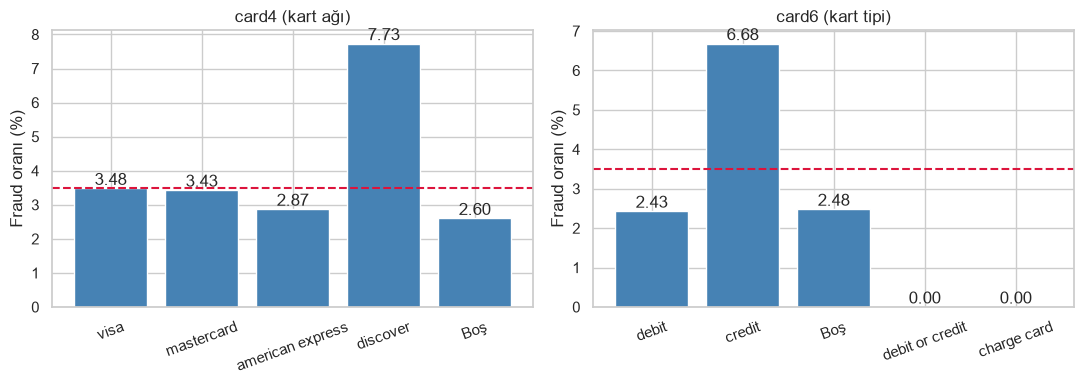

In [ ]:

# Genel kırılım fonksiyonu + card4 ve card6

def kirilim(df, col):
    """
    Bir sütunun her değeri için: işlem sayısı, işlem payı, fraud oranı, genel orana göre kat.
    NaN (boş) değerleri de ayrı bir grup olarak gösterir.
    """
    t = df.groupby(col, dropna=False, observed=True)["isFraud"].agg(
        islem_sayisi="count", fraud_orani="mean"
    )
    t["islem_payi_%"] = (t["islem_sayisi"] / len(df) * 100).round(2)
    t["fraud_orani_%"] = (t["fraud_orani"] * 100).round(2)
    t["kat"] = (t["fraud_orani"] / fraud_rate).round(2)
    return t.drop(columns="fraud_orani").sort_values("islem_sayisi", ascending=False)


# Kart sütunlarında kaç farklı değer var?
print("Farklı değer sayıları:")
print(df[["card1", "card2", "card3", "card4", "card5", "card6"]].nunique())

print("\n--- card4 (kart ağı) ---")
card4_tab = kirilim(df, "card4")
print(card4_tab)

print("\n--- card6 (kart tipi) ---")
card6_tab = kirilim(df, "card6")
print(card6_tab)

# Grafik
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, tab, title in [(axes[0], card4_tab, "card4 (kart ağı)"),
                       (axes[1], card6_tab, "card6 (kart tipi)")]:

    labels = ["Boş" if pd.isna(v) else str(v) for v in tab.index]

    bars = ax.bar(labels, tab["fraud_orani_%"], color="steelblue")
    ax.bar_label(bars, fmt="%.2f")
    ax.axhline(fraud_rate * 100, color="crimson", linestyle="--")
    ax.set_title(title)
    ax.set_ylabel("Fraud oranı (%)")
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()

fig.savefig("../src/02_fraud_by_card4_card6.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:

# Hcard1 - yüksek kardinalite ve az örnekli kategoriler

card1_tab = kirilim(df, "card1")

# Kategorilerin işlem sayısı dağılımı: çoğu card1 değeri kaç işlem içeriyor?
print("card1 farklı değer sayısı:", len(card1_tab))
print("10'dan az işlemi olan card1 değeri sayısı:", (card1_tab["islem_sayisi"] < 10).sum())
print("\nİşlem sayısı dağılımı:")
print(card1_tab["islem_sayisi"].describe().round(1))

#sadece orana göre sıralarsak en üstte ne çıkar?
print("\n[1] Fraud oranına göre en riskli 10 card1 (filtre YOK):")
print(card1_tab.sort_values("fraud_orani_%", ascending=False).head(10))

# Çözüm: en az belirli sayıda işlemi olan kategorilere bak
MIN_N = 500
print(f"\n[2] En riskli 10 card1 (en az {MIN_N} işlem şartıyla):")
print(card1_tab[card1_tab["islem_sayisi"] >= MIN_N]
      .sort_values("fraud_orani_%", ascending=False).head(10))

card1 farklı değer sayısı: 13553
10'dan az işlemi olan card1 değeri sayısı: 9255

İşlem sayısı dağılımı:
count    13553.0
mean        43.6
std        329.1
min          1.0
25%          1.0
50%          4.0
75%         14.0
max      14931.0
Name: islem_sayisi, dtype: float64

[1] Fraud oranına göre en riskli 10 card1 (filtre YOK):
       islem_sayisi  islem_payi_%  fraud_orani_%    kat
card1                                                  
3656              1           0.0          100.0  28.58
13016             1           0.0          100.0  28.58
16068             1           0.0          100.0  28.58
8185              1           0.0          100.0  28.58
16032             1           0.0          100.0  28.58
14391             1           0.0          100.0  28.58
8249              1           0.0          100.0  28.58
8507              1           0.0          100.0  28.58
1880              1           0.0          100.0  28.58
8568              1           0.0          100.0  2

In [ ]:
# P_emaildomain ve R_emaildomain kırılımı

MIN_N = 500  

for col in ["P_emaildomain", "R_emaildomain"]:
    tab = kirilim(df, col)
    print(f"\n========== {col} ==========")
    print("Farklı domain sayısı:", df[col].nunique())

    print("\nEn sık 10 domain:")
    print(tab.head(10))

    print(f"\nEn riskli 10 domain (en az {MIN_N} işlem):")
    print(tab[tab["islem_sayisi"] >= MIN_N]
          .sort_values("fraud_orani_%", ascending=False).head(10))


========== P_emaildomain ==========
Farklı domain sayısı: 59

En sık 10 domain:
               islem_sayisi  islem_payi_%  fraud_orani_%   kat
P_emaildomain                                                 
gmail.com            228354         38.67           4.35  1.24
yahoo.com            100934         17.09           2.28  0.65
NaN                   94454         15.99           2.95  0.84
hotmail.com           45250          7.66           5.30  1.51
anonymous.com         36998          6.27           2.32  0.66
aol.com               28289          4.79           2.18  0.62
comcast.net            7888          1.34           3.12  0.89
icloud.com             6267          1.06           3.14  0.90
outlook.com            5096          0.86           9.46  2.70
msn.com                4092          0.69           2.20  0.63

En riskli 10 domain (en az 500 işlem):
               islem_sayisi  islem_payi_%  fraud_orani_%   kat
P_emaildomain                                               

Domain sayısı   : 59
Sağlayıcı sayısı: 44

En sık 10 sağlayıcı:
                  islem_sayisi  islem_payi_%  fraud_orani_%   kat
P_email_provider                                                 
gmail                   228850         38.75           4.35  1.24
yahoo                   102909         17.43           2.25  0.64
NaN                      94454         15.99           2.95  0.84
hotmail                  46005          7.79           5.25  1.50
anonymous                36998          6.27           2.32  0.66
aol                      28289          4.79           2.18  0.62
comcast                   7888          1.34           3.12  0.89
icloud                    6267          1.06           3.14  0.90
outlook                   5534          0.94           9.74  2.78
msn                       4092          0.69           2.20  0.63


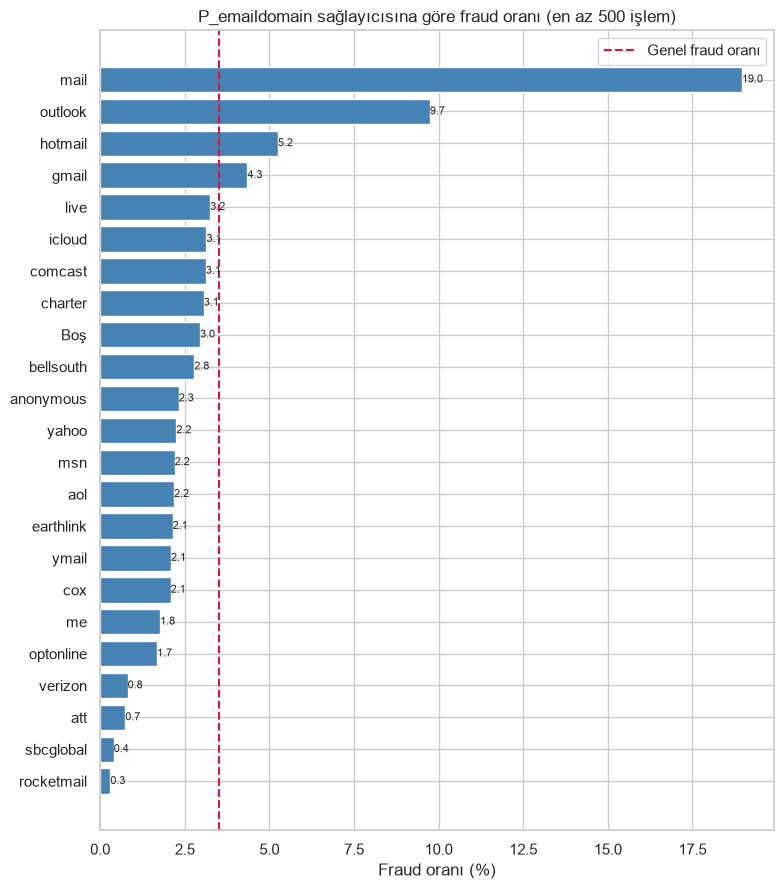

In [ ]:
# Domain'leri sağlayıcıya göre gruplama (gmail.com + gmail -> gmail)

# "string" tipine çeviriyoruz: bu tip boş değerleri <NA> olarak korur.
p_dom = df["P_emaildomain"].astype("string")

# Noktaya göre böl, ilk parçayı al:
#   "gmail.com"   -> "gmail"
df["P_email_provider"] = p_dom.str.split(".").str[0]

# Gruplamadan önce ve sonra kaç farklı değer var?
print("Domain sayısı   :", df["P_emaildomain"].nunique())
print("Sağlayıcı sayısı:", df["P_email_provider"].nunique())

prov_tab = kirilim(df, "P_email_provider")
print("\nEn sık 10 sağlayıcı:")
print(prov_tab.head(10))

# Grafik
plot_tab = (prov_tab[prov_tab["islem_sayisi"] >= MIN_N]
            .sort_values("fraud_orani_%"))  

labels = ["Boş" if pd.isna(v) else str(v) for v in plot_tab.index] 

fig, ax = plt.subplots(figsize=(8, 0.35 * len(plot_tab) + 1)) 
bars = ax.barh(labels, plot_tab["fraud_orani_%"], color="steelblue")
ax.bar_label(bars, fmt="%.1f", fontsize=8)
ax.axvline(fraud_rate * 100, color="crimson", linestyle="--", label="Genel fraud oranı")
ax.set_xlabel("Fraud oranı (%)")
ax.set_title(f"P_emaildomain sağlayıcısına göre fraud oranı (en az {MIN_N} işlem)")
ax.legend()
plt.tight_layout()

fig.savefig("../src/02_fraud_by_email_provider.png", dpi=150, bbox_inches="tight")
plt.show()

## Sonuç: EDA Özeti ve Feature Engineering Kararları

Bu notebook'ta 590.537 işlemlik birleştirilmiş IEEE-CIS verisi incelendi. Amaç, fraud'u ayırt eden örüntüleri bulmak ve bir sonraki adımda (03_feature_engineering) hangi feature'ların oluşturulacağına ve modelin nasıl doğrulanacağına karar vermekti.

Analiz boyunca yalnızca tek tek değişkenlere bakılmadı. Bir değişkende görülen etkinin gerçekten o değişkenden mi, yoksa başka bir değişkenden mi (özellikle ürün tipinden) kaynaklandığı da kontrol edildi.

---

### 1. Bulgular

#### 1.1 Sınıf dengesizliği
- **Ne gördük:** İşlemlerin %3,50'si fraud (20.663 / 590.537). Her 1 fraud işleme karşılık ~28 normal işlem var.
- **Ne anlama geliyor:** Her işleme "normal" diyen bir model bile %96,5 accuracy alır. Bu yüzden accuracy bu problemde anlamsız bir metrik.
- **Ne yapacağız:** Model performansı PR-AUC ve ROC-AUC ile ölçülecek. Dengesizlik oranı (~28), modelde sınıf ağırlığı (`scale_pos_weight`) ayarı için başlangıç noktası olacak.

#### 1.2 Ürün tipi (ProductCD): en güçlü kırılım
- **Ne gördük:** C ürün grubu işlemlerin yalnızca %11,6'sı, ama fraud'ların %38,8'i (fraud oranı %11,69, genelin 3,3 katı). W grubu işlemlerin %74,5'i ve en güvenli grup (%2,04).
- **Ne anlama geliyor:** Ürün tipi, fraud riskini en net ayıran değişken. Ayrıca diğer birçok değişkendeki etkinin arkasında da ürün tipi var. Bu yüzden diğer bulgular yorumlanırken ürün etkisi ayrıca kontrol edildi.
- **Ne yapacağız:** ProductCD modelde kategorik feature olarak kullanılacak.

#### 1.3 Identity bilgisi
- **Ne gördük:** İlk bakışta identity kaydı olan işlemler ~3,8 kat daha riskli görünüyordu (%7,85 ve %2,09). Ancak W ürününde hiç identity kaydı yok, diğer ürünlerde ise neredeyse hep var.
- **Ne anlama geliyor:** İlk bakıştaki farkın büyük kısmı aslında "W, diğer ürünlerden daha güvenli" bilgisi. Identity bayrağı bu ürün farkını taşıyordu. Yine de C ürünü içinde identity'si olan işlemler ~2,1 kat daha riskli (%12,28 ve %5,82). Yani identity'nin ürün dışında da küçük bir kendi etkisi var.
- **Ne yapacağız:** `has_identity` bayrağı tutulacak, ama önemli bilgisinin çoğunun ProductCD ile örtüştüğü bilinerek. Feature importance yorumlanırken bu ikisinin öneminin birbirine bölünebileceği dikkate alınacak.

#### 1.4 Eksik değerler
- **Ne gördük:** Adres bilgisi (addr1/addr2) olmayan işlemlerde fraud oranı ~4,8 kat yüksek (%11,78 ve %2,46). addr1 ve addr2 her zaman birlikte boş. Buna karşılık dist2 ve R_emaildomain çoğu işlemde boş ve dolu olmaları riskli. R_emaildomain dolu işlemlerin %95,5'inde identity kaydı da var.
- **Ne anlama geliyor:** Veride boşluklar rastgele değil, bilgi taşıyor. Bir alanın boş olması bazen riskin, bazen güvenin işareti. Boşlukları ortalama/medyan ile doldurmak bu bilgiyi yok eder.
- **Ne yapacağız:** Eksik değerler doldurulmayacak, NaN olarak bırakılacak (LightGBM/XGBoost NaN'ı doğrudan kullanabilir). Gerekli yerlerde eksiklik bayrakları eklenecek (`has_addr`).

#### 1.5 Günün saati
- **Ne gördük:** İşlem hacminin en düşük olduğu saatlerde (göreli 5-10) fraud oranı 2-3 kat artıyor (saat 7'de %10,6). Bu etki hem C hem W ürünü içinde ayrı ayrı görülüyor. C ürününde gece saatlerinde işlemlerin ~1/3'ü fraud.
- **Ne anlama geliyor:** Saat etkisi gerçek ve ürün tipinden bağımsız. Mekanizma şu: gece normal işlemler ~17 kat azalırken fraud işlemler ~6 kat azalıyor. Ancak bu saatler fraud'ların yalnızca ~%10'unu içeriyor (oran yüksek, pay küçük).
- **Ne yapacağız:** `tx_hour` feature olarak eklenecek. Not: TransactionDT gerçek bir tarih değil, bu yüzden saatler göreli. Gerçek saat dilimi bilinmiyor.

#### 1.6 Zaman içindeki değişim
- **Ne gördük:** Haftalık fraud oranı 6 ay içinde %1,85 ile %5,06 arasında değişiyor. İlk 4 haftada işlem hacmi yüksek (muhtemelen bir alışveriş sezonu), fraud oranı düşük.
- **Ne anlama geliyor:** Veri zamanla sabit değil. Model geçmişten öğrenip geleceği tahmin edeceği için, geçmiş ile gelecek arasındaki bu farklılık modelin gerçek performansını etkiler.
- **Ne yapacağız:** Train/validation ayrımı **zamana göre** yapılacak (eski işlemler train, yeni işlemler validation). Rastgele bölme, modelin "gelecekten" örnek görmesine yol açar ve performansı olduğundan iyi gösterir.

#### 1.7 İşlem tutarı
- **Ne gördük:** Tipik (medyan) fraud ve normal işlem tutarları birbirine yakın ($75 ve $68,5). Fraud tutarları daha dağınık. Çok büyük işlemler (>~$1.500) neredeyse tamamen normal. Dağılımdaki keskin tepeler ürünlerin sabit fiyatlarına ait (~$50 → H, ~$100 → R). En riskli ürün C ise küçük tutarlarda yoğunlaşıyor.
- **Ne anlama geliyor:** Tutar tek başına zayıf bir sinyal ve tutar örüntülerinin büyük kısmı ürün farkından geliyor.
- **Ne yapacağız:** Tutar log ölçekte (`log1p`) kullanılacak. Kuruş kısmı ayrı bir feature olarak denenecek. Ağaç modelleri tutarı ProductCD ile birlikte kullanarak ürün içi farkları öğrenebilir.

#### 1.8 Kart bilgileri
- **Ne gördük:** Kredi kartı işlemleri banka kartına göre ~2,7 kat riskli (%6,68 ve %2,43). Discover kartlar 2,2 kat riskli ama küçük bir grup. card1'de 13.553 farklı değer var. Bunların %68'inin 10'dan az işlemi var. En az 500 işlemi olan bazı card1 değerlerinde fraud oranı %17-33.
- **Ne anlama geliyor:** card6 (kart tipi) güçlü ve yorumlanabilir bir sinyal. card1 çok güçlü, ama binlerce değeri olduğu için doğrudan kullanılması zor.
- **Ne yapacağız:** card4 ve card6 kategorik olarak kullanılacak. card1 için frekans kodlama yapılacak. Target encoding yalnızca train verisiyle ve sızıntıyı önleyecek şekilde (out-of-fold) denenecek.

#### 1.9 E-posta domain'leri
- **Ne gördük:** Ödemeyi yapanın e-postasında Microsoft ailesi (outlook %9,7, hotmail %5,3) ve mail.com (%19) riskli. İnternet servis sağlayıcılarının e-postaları (att, verizon, sbcglobal) en güvenli (%0,4-0,8). gmail ortalamanın biraz üstünde (%4,35), ama işlemlerin %38,7'sini oluşturduğu için fraud'ların yaklaşık yarısı gmail işlemlerinde. anonymous.com beklenenin aksine riskli değil. Alıcı e-postasında (R_emaildomain) dolu domain'lerin çoğu riskli görünüyor, ama bu büyük ölçüde ürün etkisi.
- **Ne anlama geliyor:** E-posta sağlayıcısının tipi (ücretsiz ve kolay açılan webmail ile gerçek bir aboneliğe bağlı ISP e-postası) riskle ilişkili görünüyor. Bu bir hipotez, ama veriyle uyumlu.
- **Ne yapacağız:** Domain'ler sağlayıcıya göre gruplanacak (59 → 44 değer). Sağlayıcı tipi, P ve R domain'lerinin aynı olup olmadığı ve ülke uzantısı (.mx, .jp) feature olarak denenecek.

#### 1.10 Tekrar eden işlemler
- **Ne gördük:** Aynı anda, aynı kart ve tutarla yapılan işlemler (102 işlem) ~5 kat riskli. Bu kümedeki fraud'lar birkaç grupta toplanmış ve o grupların tamamı fraud. Farklı zamanlarda her detayıyla tekrarlanan işlemler (904 işlem) ise çok güvenli (%0,7).
- **Ne anlama geliyor:** Tekrar tek başına şüpheli değil. Önemli olan zaman: kısa sürede tekrar riskli, düzenli aralıklarla tekrar (muhtemelen abonelik) güvenli.
- **Ne yapacağız:** Etkilenen işlem sayısı küçük, ama fikir genelleştirilecek: "bu kart kısa süre içinde kaç işlem yaptı?" gibi davranış (velocity) feature'ları oluşturulacak.

---

- **Tek boyutlu kırılımlar yanıltıcı olabilir.** Identity ve tutar etkilerinin büyük kısmı ürün tipinden geliyordu. Saat etkisi ise ürün kontrolünden sonra da sağlam kaldı. Bir etkiyi yorumlamadan önce, başka bir değişkenin o etkiyi taşıyıp taşımadığı kontrol edilmeli.
- **Az örnekli kategorilerin oranlarına güvenilmez.** card1'de filtresiz sıralamada en riskli görünen değerlerin hepsi 1 işlemlik ve %100 fraud'du. Bu yüzden kategoriler en az işlem sayısı filtresiyle (≥500) değerlendirildi.
- **"Oran yüksek" ile "pay büyük" farklı şeyler.** Gece saatlerinde fraud oranı yüksek ama fraud'ların küçük bir kısmı orada. W ürünü ve gmail'de oran düşük-orta ama fraud'ların büyük kısmı orada. Model her iki tür örüntüyü de yakalamalı.
- **Sezgiyi veriyle test etmek gerekiyor.** "Anonim e-posta riskli olmalı" beklentisi veriyle desteklenmedi.

---

### 2. Açık kalan sorular
- Kredi kartı etkisinin ne kadarı ürün tipinden kaynaklanıyor?
- R_emaildomain'in ürün etkisi dışında kendi etkisi var mı? (Ürün içinde, özellikle C'de incelenmeli.)
- card1 + adres + e-posta kombinasyonu kullanıcıyı ne kadar iyi tanımlıyor?

---

### 3. Not
Bu notebook'ta türetilen sütunlar (`has_identity`, `tx_hour`, `tx_dow`, `tx_day`, `P_email_provider`) parquet dosyasına kaydedilmedi. EDA notebook'u keşif içindir. Tüm feature'lar 03_feature_engineering'de tek bir yerde, tekrarlanabilir şekilde yeniden oluşturulacak.